# Eye-Tracking Analysis: Active/Passive Voice in English and Punjabi

This notebook analyzes eye-tracking data from a visual-world paradigm experiment comparing **English** and **Punjabi** sentence processing across **Active**, **Passive**, and **Passive-dropped** voice types.

## Experimental Design
- **48 bilingual participants** viewed images of transitive events
- **Two sessions**: Free Viewing (baseline) and Voice-guided
- **Six voice conditions**: English Active, English Passive, English Passive-dropped, Punjabi Active, Punjabi Passive, Punjabi Passive-dropped
- **AOIs**: Subject (agent) and Object (patient)

## Analysis Structure
1. **Free Viewing vs Voice** — Baseline effect of linguistic input
2. **Voice Type Effects** — Active vs Passive vs Passive-dropped
3. **Language Effects** — English vs Punjabi
4. **First Fixation Analysis**
5. **Temporal Dynamics**

## Cell 1 — Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', context='paper', font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

# Paths
DATA_DIR = Path('data/processed')
RESULTS_DIR = Path('results/cleaned_analysis')
PLOTS_DIR = RESULTS_DIR / 'plots'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Constants
FREE_VIEW_LABEL = 'Free Viewing'
VOICE_LABEL = 'Voice'
UNDEFINED = 'UNDEFINEDnull'

print('Setup complete.')

Setup complete.


## Cell 2 — Load Data

In [2]:
# Load pre-processed datasets
print('Loading fixation data...')
fixation_df = pd.read_csv(DATA_DIR / 'fixation_with_variables.csv')
print(f'  Fixation records: {len(fixation_df):,}')

print('Loading saccade data...')
saccade_df = pd.read_csv(DATA_DIR / 'saccade_with_variables.csv')
print(f'  Saccade records: {len(saccade_df):,}')

print('Loading interest area data...')
ia_df = pd.read_csv(DATA_DIR / 'interest_area_with_variables.csv')
print(f'  Interest area records: {len(ia_df):,}')

print('\nAll data loaded.')

Loading fixation data...
  Fixation records: 25,352
Loading saccade data...
  Saccade records: 23,821
Loading interest area data...
  Interest area records: 3,888

All data loaded.


## Cell 3 — Condition Engineering

Key insight: trials with `session_var == 'free_view'` (and `voice_id == 'UNDEFINEDnull'`) are **free-viewing baseline** trials — not missing data.

In [7]:
def engineer_conditions(df, df_name=''):
    """Add condition, voice_type, and language_clean columns.
    
    - condition: 'Free Viewing' or 'Voice'
    - voice_type: 'Free Viewing', 'Active', 'Passive', 'Passive-dropped'
    - language_clean: 'None' (free viewing), 'English', or 'Punjabi'
    """
    n_before = len(df)
    
    # 1. Create condition: free viewing vs voice-guided
    df['condition'] = np.where(
        (df['session_var'] == 'free_view') | (df['voice_id'] == UNDEFINED) | (df['voice_id'].isna()),
        FREE_VIEW_LABEL,
        VOICE_LABEL
    )
    
    # 2. Create voice_type
    def map_voice_type(row):
        if row['condition'] == FREE_VIEW_LABEL:
            return FREE_VIEW_LABEL
        vt = str(row.get('voice_type_category', '')).strip()
        if vt in ('Active', 'Passive', 'Passive-dropped'):
            return vt
        # Try to infer from voice_id
        vid = str(row.get('voice_id', '')).lower()
        if 'active' in vid:
            return 'Active'
        elif 'dropped' in vid or 'drop' in vid:
            return 'Passive-dropped'
        elif 'passive' in vid:
            return 'Passive'
        return 'Unknown'
    
    df['voice_type'] = df.apply(map_voice_type, axis=1)
    
    # 3. Create language_clean
    def map_language(row):
        if row['condition'] == FREE_VIEW_LABEL:
            return 'None'
        lang = str(row.get('language', '')).strip()
        if lang in ('English', 'Punjabi'):
            return lang
        # Try to infer from voice_id or other columns
        vid = str(row.get('voice_id', '')).lower()
        if 'english' in vid or 'eng' in vid:
            return 'English'
        elif 'punjabi' in vid or 'pun' in vid:
            return 'Punjabi'
        return 'Unknown'
    
    df['language_clean'] = df.apply(map_language, axis=1)
    
    # Report
    print(f'\n{df_name} ({len(df):,} records):')
    print(f'  Condition: {dict(df["condition"].value_counts())}')
    print(f'  Voice Type: {dict(df["voice_type"].value_counts())}')
    print(f'  Language: {dict(df["language_clean"].value_counts())}')
    
    return df


fixation_df = engineer_conditions(fixation_df, 'Fixation')
saccade_df = engineer_conditions(saccade_df, 'Saccade')
ia_df = engineer_conditions(ia_df, 'Interest Area')

print('\nCondition engineering complete.')


Fixation (25,352 records):
  Condition: {'Free Viewing': np.int64(13112), 'Voice': np.int64(12240)}
  Voice Type: {'Free Viewing': np.int64(13112), 'Passive': np.int64(8014), 'Active': np.int64(4226)}
  Language: {'None': np.int64(13112), 'Unknown': np.int64(12240)}

Saccade (23,821 records):
  Condition: {'Free Viewing': np.int64(12329), 'Voice': np.int64(11492)}
  Voice Type: {'Free Viewing': np.int64(12329), 'Passive': np.int64(7516), 'Active': np.int64(3976)}
  Language: {'None': np.int64(12329), 'Unknown': np.int64(11492)}

Interest Area (3,888 records):
  Condition: {'Free Viewing': np.int64(1944), 'Voice': np.int64(1944)}
  Voice Type: {'Free Viewing': np.int64(1944), 'Passive': np.int64(1296), 'Active': np.int64(648)}
  Language: {'None': np.int64(1944), 'Unknown': np.int64(1944)}

Condition engineering complete.


## Cell 4 — Data Quality Summary

In [8]:
# Focus on subject vs object AOIs (exclude 'other')
fix_so = fixation_df[fixation_df['aoi_type'].isin(['subject', 'object'])].copy()
sac_so = saccade_df.copy()  # saccades don't have AOI in the same way

print('='*60)
print('DATA QUALITY SUMMARY')
print('='*60)

# Participants
n_participants = fixation_df['participant_id'].nunique()
print(f'\nParticipants: {n_participants}')

# Trials by condition
trial_ids = fixation_df.groupby('condition')['trial_id'].nunique()
print(f'\nTrials by condition:')
for cond, n in trial_ids.items():
    print(f'  {cond}: {n:,}')

# Fixation counts
print(f'\nFixation records (subject + object AOI only): {len(fix_so):,}')
fix_counts = fix_so.groupby(['condition', 'aoi_type']).size()
print(fix_counts.to_string())

# Voice-guided breakdown
voice_fix = fix_so[fix_so['condition'] == VOICE_LABEL]
if len(voice_fix) > 0:
    print(f'\nVoice-guided fixations by voice type and AOI:')
    vt_counts = voice_fix.groupby(['voice_type', 'aoi_type']).size()
    print(vt_counts.to_string())
    
    print(f'\nVoice-guided fixations by language and AOI:')
    lang_counts = voice_fix.groupby(['language_clean', 'aoi_type']).size()
    print(lang_counts.to_string())

# Summary stats for fixation duration
print(f'\nFixation Duration Summary (ms):')
dur_stats = fix_so.groupby('condition')['CURRENT_FIX_DURATION'].describe()
print(dur_stats.round(2).to_string())

DATA QUALITY SUMMARY

Participants: 49

Trials by condition:
  Free Viewing: 882
  Voice: 882

Fixation records (subject + object AOI only): 21,889
condition     aoi_type
Free Viewing  object      6198
              subject     5196
Voice         object      5706
              subject     4789

Voice-guided fixations by voice type and AOI:
voice_type  aoi_type
Active      object      1906
            subject     1688
Passive     object      3800
            subject     3101

Voice-guided fixations by language and AOI:
language_clean  aoi_type
Unknown         object      5706
                subject     4789

Fixation Duration Summary (ms):
                count    mean     std  min    25%    50%    75%     max
condition                                                              
Free Viewing  11394.0  339.00  332.90  3.0  174.0  244.0  378.0  4993.0
Voice         10495.0  358.22  359.86  2.0  178.0  252.0  406.0  4992.0


## Cell 5 — Comparison 1: Free Viewing vs Voice (Baseline Effect)

Does linguistic input change how participants distribute visual attention between agent and patient?

COMPARISON 1: FREE VIEWING vs VOICE-GUIDED

--- Fixation Duration (ms) ---
    AOI  Free Viewing_n  Free Viewing_mean  Free Viewing_sd  Voice_n  Voice_mean   Voice_sd  Difference  Mann-Whitney U  p-value   Cohen_d Significant
subject            5196         347.151463       346.691035     4789  360.873042 345.047232  -13.721580      11979866.0 0.001326 -0.039669          **
 object            6198         332.167312       320.745751     5706  355.995093 371.846339  -23.827781      17198473.5 0.009704 -0.068830          **

--- Fixation Count per Trial ---
    AOI  Free Viewing_n  Free Viewing_mean  Free Viewing_sd  Voice_n  Voice_mean  Voice_sd  Difference  Mann-Whitney U  p-value  Cohen_d Significant
subject             870           5.972414         3.429269      849    5.640754  3.467407    0.331660        393474.5 0.018268 0.096185           *
 object             873           7.099656         3.786797      859    6.642608  3.682517    0.457049        400487.5 0.013779 0.122355    

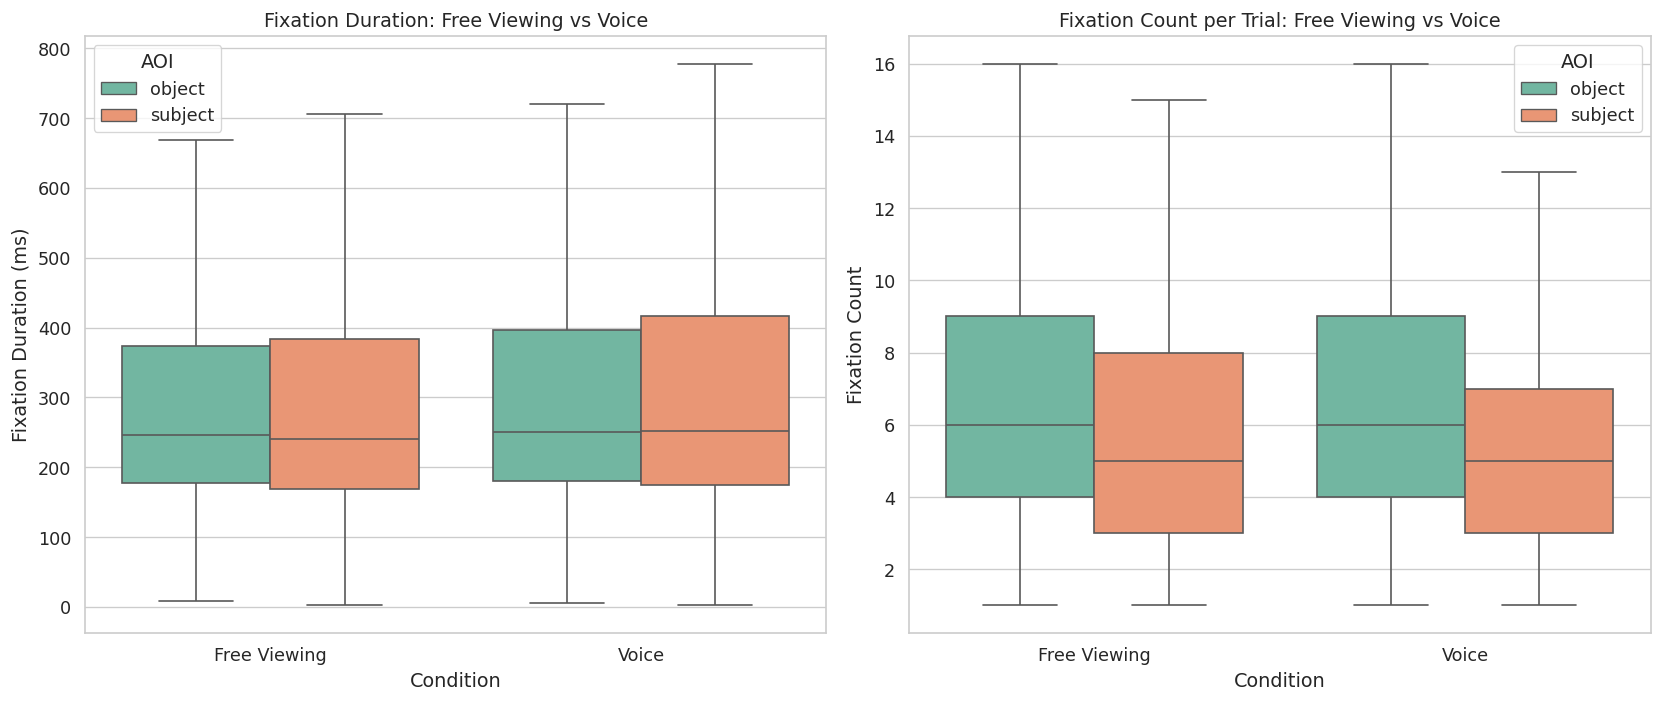


Saved: results/cleaned_analysis/plots/comparison1_freeview_vs_voice.png


In [9]:
def cohens_d(group1, group2):
    """Compute Cohen's d effect size."""
    n1, n2 = len(group1), len(group2)
    if n1 == 0 or n2 == 0:
        return np.nan
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    if pooled_std == 0:
        return np.nan
    return (group1.mean() - group2.mean()) / pooled_std


def compare_two_groups(df, group_col, group1_val, group2_val, metric_col, aoi_col='aoi_type'):
    """Compare a metric across two groups, broken down by AOI type."""
    results = []
    for aoi in ['subject', 'object']:
        d1 = df[(df[group_col] == group1_val) & (df[aoi_col] == aoi)][metric_col].dropna()
        d2 = df[(df[group_col] == group2_val) & (df[aoi_col] == aoi)][metric_col].dropna()
        
        if len(d1) > 0 and len(d2) > 0:
            u_stat, p_val = stats.mannwhitneyu(d1, d2, alternative='two-sided')
            d = cohens_d(d1, d2)
            results.append({
                'AOI': aoi,
                f'{group1_val}_n': len(d1),
                f'{group1_val}_mean': d1.mean(),
                f'{group1_val}_sd': d1.std(),
                f'{group2_val}_n': len(d2),
                f'{group2_val}_mean': d2.mean(),
                f'{group2_val}_sd': d2.std(),
                'Difference': d1.mean() - d2.mean(),
                'Mann-Whitney U': u_stat,
                'p-value': p_val,
                'Cohen_d': d,
                'Significant': '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))
            })
    return pd.DataFrame(results)


print('='*70)
print('COMPARISON 1: FREE VIEWING vs VOICE-GUIDED')
print('='*70)

# 1a. Fixation Duration
print('\n--- Fixation Duration (ms) ---')
dur_results = compare_two_groups(fix_so, 'condition', FREE_VIEW_LABEL, VOICE_LABEL, 'CURRENT_FIX_DURATION')
print(dur_results.to_string(index=False))

# 1b. Fixation Count per trial
trial_fix_counts = fix_so.groupby(['condition', 'aoi_type', 'trial_id']).size().reset_index(name='fix_count')
print('\n--- Fixation Count per Trial ---')
fc_results = compare_two_groups(trial_fix_counts, 'condition', FREE_VIEW_LABEL, VOICE_LABEL, 'fix_count')
print(fc_results.to_string(index=False))

# 1c. Dwell Time (if available)
if 'CURRENT_FIX_INTEREST_AREA_DWELL_TIME' in fix_so.columns:
    print('\n--- Dwell Time (ms) ---')
    dwell_results = compare_two_groups(fix_so, 'condition', FREE_VIEW_LABEL, VOICE_LABEL, 'CURRENT_FIX_INTEREST_AREA_DWELL_TIME')
    print(dwell_results.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Fixation duration by condition and AOI
sns.boxplot(data=fix_so, x='condition', y='CURRENT_FIX_DURATION', hue='aoi_type',
            palette='Set2', ax=axes[0], showfliers=False)
axes[0].set_title('Fixation Duration: Free Viewing vs Voice')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Fixation Duration (ms)')
axes[0].legend(title='AOI')

# Fixation count per trial by condition and AOI
sns.boxplot(data=trial_fix_counts, x='condition', y='fix_count', hue='aoi_type',
            palette='Set2', ax=axes[1], showfliers=False)
axes[1].set_title('Fixation Count per Trial: Free Viewing vs Voice')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Fixation Count')
axes[1].legend(title='AOI')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'comparison1_freeview_vs_voice.png', bbox_inches='tight')
plt.show()
print(f'\nSaved: {PLOTS_DIR / "comparison1_freeview_vs_voice.png"}')

## Cell 6 — Comparison 2: Voice Type Effects

Among voice-guided trials, does voice type (Active / Passive / Passive-dropped) affect attention to agent vs patient?

In [ ]:
# Filter to voice-guided trials with known voice type only
voice_fix = fix_so[
    (fix_so['condition'] == VOICE_LABEL) &
    (fix_so['voice_type'].isin(['Active', 'Passive', 'Passive-dropped']))
].copy()

print('='*70)
print('COMPARISON 2: VOICE TYPE EFFECTS (Active vs Passive vs Passive-dropped)')
print('='*70)
print(f'Voice-guided fixations (subject/object): {len(voice_fix):,}')
print(f'By voice type: {dict(voice_fix["voice_type"].value_counts())}')

# Descriptive stats
print('\n--- Fixation Duration by Voice Type and AOI ---')
desc = voice_fix.groupby(['voice_type', 'aoi_type'])['CURRENT_FIX_DURATION'].agg(
    ['count', 'mean', 'median', 'std']
).round(2)
print(desc.to_string())

# Kruskal-Wallis test (3 groups) for each AOI
print('\n--- Kruskal-Wallis Tests ---')
for aoi in ['subject', 'object']:
    groups = []
    labels = []
    for vt in ['Active', 'Passive', 'Passive-dropped']:
        g = voice_fix[(voice_fix['voice_type'] == vt) & (voice_fix['aoi_type'] == aoi)]['CURRENT_FIX_DURATION'].dropna()
        if len(g) > 0:
            groups.append(g)
            labels.append(vt)
    
    if len(groups) >= 2:
        h_stat, p_val = stats.kruskal(*groups)
        sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))
        print(f'  AOI={aoi}: H={h_stat:.2f}, p={p_val:.6f} ({sig})')
        
        # Pairwise Mann-Whitney U if significant
        if p_val < 0.05:
            print(f'  Pairwise comparisons for {aoi}:')
            for i in range(len(groups)):
                for j in range(i+1, len(groups)):
                    u, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
                    d = cohens_d(groups[i], groups[j])
                    sig2 = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
                    print(f'    {labels[i]} vs {labels[j]}: U={u:.0f}, p={p:.6f}, d={d:.3f} ({sig2})')

# Fixation count per trial by voice type
trial_voice_counts = voice_fix.groupby(['voice_type', 'aoi_type', 'trial_id']).size().reset_index(name='fix_count')

print('\n--- Fixation Count per Trial by Voice Type ---')
fc_desc = trial_voice_counts.groupby(['voice_type', 'aoi_type'])['fix_count'].agg(
    ['count', 'mean', 'median', 'std']
).round(2)
print(fc_desc.to_string())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=voice_fix, x='voice_type', y='CURRENT_FIX_DURATION', hue='aoi_type',
            palette='Set2', ax=axes[0], showfliers=False,
            order=['Active', 'Passive', 'Passive-dropped'])
axes[0].set_title('Fixation Duration by Voice Type')
axes[0].set_xlabel('Voice Type')
axes[0].set_ylabel('Fixation Duration (ms)')
axes[0].legend(title='AOI')

sns.boxplot(data=trial_voice_counts, x='voice_type', y='fix_count', hue='aoi_type',
            palette='Set2', ax=axes[1], showfliers=False,
            order=['Active', 'Passive', 'Passive-dropped'])
axes[1].set_title('Fixation Count per Trial by Voice Type')
axes[1].set_xlabel('Voice Type')
axes[1].set_ylabel('Fixation Count')
axes[1].legend(title='AOI')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'comparison2_voice_type_effects.png', bbox_inches='tight')
plt.show()
print(f'\nSaved: {PLOTS_DIR / "comparison2_voice_type_effects.png"}')

## Cell 7 — Comparison 3: Language Effects

Does language (English vs Punjabi) affect visual attention patterns? This is the key cross-linguistic test.

In [ ]:
# Filter to voice-guided trials with known language
lang_fix = fix_so[
    (fix_so['condition'] == VOICE_LABEL) &
    (fix_so['language_clean'].isin(['English', 'Punjabi']))
].copy()

print('='*70)
print('COMPARISON 3: LANGUAGE EFFECTS (English vs Punjabi)')
print('='*70)
print(f'Language fixations (subject/object): {len(lang_fix):,}')
print(f'By language: {dict(lang_fix["language_clean"].value_counts())}')

# Descriptive stats
print('\n--- Fixation Duration by Language and AOI ---')
desc = lang_fix.groupby(['language_clean', 'aoi_type'])['CURRENT_FIX_DURATION'].agg(
    ['count', 'mean', 'median', 'std']
).round(2)
print(desc.to_string())

# Mann-Whitney U for English vs Punjabi
print('\n--- Statistical Tests ---')
lang_results = compare_two_groups(lang_fix, 'language_clean', 'English', 'Punjabi', 'CURRENT_FIX_DURATION')
print(lang_results.to_string(index=False))

# Language × Voice Type interaction
print('\n--- Language × Voice Type Breakdown ---')
lang_vt_fix = lang_fix[lang_fix['voice_type'].isin(['Active', 'Passive', 'Passive-dropped'])]
if len(lang_vt_fix) > 0:
    interaction = lang_vt_fix.groupby(['language_clean', 'voice_type', 'aoi_type'])['CURRENT_FIX_DURATION'].agg(
        ['count', 'mean', 'std']
    ).round(2)
    print(interaction.to_string())

# Fixation count per trial
trial_lang_counts = lang_fix.groupby(['language_clean', 'aoi_type', 'trial_id']).size().reset_index(name='fix_count')
print('\n--- Fixation Count per Trial by Language ---')
fc_results = compare_two_groups(trial_lang_counts, 'language_clean', 'English', 'Punjabi', 'fix_count')
print(fc_results.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Duration by language
sns.boxplot(data=lang_fix, x='language_clean', y='CURRENT_FIX_DURATION', hue='aoi_type',
            palette='Set2', ax=axes[0], showfliers=False)
axes[0].set_title('Fixation Duration by Language')
axes[0].set_xlabel('Language')
axes[0].set_ylabel('Fixation Duration (ms)')
axes[0].legend(title='AOI')

# Count by language
sns.boxplot(data=trial_lang_counts, x='language_clean', y='fix_count', hue='aoi_type',
            palette='Set2', ax=axes[1], showfliers=False)
axes[1].set_title('Fixation Count per Trial by Language')
axes[1].set_xlabel('Language')
axes[1].set_ylabel('Fixation Count')
axes[1].legend(title='AOI')

# Language × Voice Type × AOI interaction (bar plot)
if len(lang_vt_fix) > 0:
    means = lang_vt_fix.groupby(['language_clean', 'voice_type', 'aoi_type'])['CURRENT_FIX_DURATION'].mean().reset_index()
    means['group'] = means['language_clean'] + ' - ' + means['voice_type']
    sns.barplot(data=means, x='group', y='CURRENT_FIX_DURATION', hue='aoi_type',
                palette='Set2', ax=axes[2])
    axes[2].set_title('Language × Voice Type × AOI')
    axes[2].set_xlabel('')
    axes[2].set_ylabel('Mean Fix Duration (ms)')
    axes[2].tick_params(axis='x', rotation=45)
    axes[2].legend(title='AOI')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'comparison3_language_effects.png', bbox_inches='tight')
plt.show()
print(f'\nSaved: {PLOTS_DIR / "comparison3_language_effects.png"}')

## Cell 8 — First Fixation Analysis

Which AOI (agent or patient) receives the first non-central fixation? This tests the Agent-First hypothesis.

In [ ]:
# Get first fixation per trial that lands on subject or object
first_fix = fix_so.sort_values(['trial_id', 'CURRENT_FIX_INDEX'])
first_fix = first_fix.groupby('trial_id').first().reset_index()

print('='*70)
print('FIRST FIXATION ANALYSIS')
print('='*70)

# Overall first fixation preference
print('\n--- Overall First Fixation on Subject vs Object ---')
ff_counts = first_fix['aoi_type'].value_counts()
ff_pcts = (ff_counts / ff_counts.sum() * 100).round(1)
for aoi in ['subject', 'object']:
    if aoi in ff_counts.index:
        print(f'  {aoi}: {ff_counts[aoi]} ({ff_pcts[aoi]}%)')

# Chi-square test: is there a preference?
if 'subject' in ff_counts.index and 'object' in ff_counts.index:
    observed = [ff_counts['subject'], ff_counts['object']]
    chi2, p = stats.chisquare(observed)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'  Chi-square: χ²={chi2:.2f}, p={p:.6f} ({sig})')

# By condition
print('\n--- First Fixation by Condition ---')
for cond in [FREE_VIEW_LABEL, VOICE_LABEL]:
    subset = first_fix[first_fix['condition'] == cond]
    counts = subset['aoi_type'].value_counts()
    pcts = (counts / counts.sum() * 100).round(1)
    print(f'  {cond}:')
    for aoi in ['subject', 'object']:
        if aoi in counts.index:
            print(f'    {aoi}: {counts[aoi]} ({pcts[aoi]}%)')
    if 'subject' in counts.index and 'object' in counts.index:
        chi2, p = stats.chisquare([counts['subject'], counts['object']])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'    χ²={chi2:.2f}, p={p:.6f} ({sig})')

# By voice type
print('\n--- First Fixation by Voice Type ---')
for vt in [FREE_VIEW_LABEL, 'Active', 'Passive', 'Passive-dropped']:
    subset = first_fix[first_fix['voice_type'] == vt]
    if len(subset) == 0:
        continue
    counts = subset['aoi_type'].value_counts()
    pcts = (counts / counts.sum() * 100).round(1)
    print(f'  {vt}:')
    for aoi in ['subject', 'object']:
        if aoi in counts.index:
            print(f'    {aoi}: {counts[aoi]} ({pcts[aoi]}%)')

# By language
print('\n--- First Fixation by Language ---')
for lang in ['None', 'English', 'Punjabi']:
    subset = first_fix[first_fix['language_clean'] == lang]
    if len(subset) == 0:
        continue
    counts = subset['aoi_type'].value_counts()
    pcts = (counts / counts.sum() * 100).round(1)
    label = 'Free Viewing' if lang == 'None' else lang
    print(f'  {label}:')
    for aoi in ['subject', 'object']:
        if aoi in counts.index:
            print(f'    {aoi}: {counts[aoi]} ({pcts[aoi]}%)')

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# By condition
ct1 = pd.crosstab(first_fix['condition'], first_fix['aoi_type'], normalize='index') * 100
ct1[['subject', 'object']].plot(kind='bar', ax=axes[0], color=['#66c2a5', '#fc8d62'])
axes[0].set_title('First Fixation by Condition')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AOI')
axes[0].axhline(y=50, color='gray', linestyle='--', alpha=0.5)

# By voice type
vt_order = [FREE_VIEW_LABEL, 'Active', 'Passive', 'Passive-dropped']
ff_vt = first_fix[first_fix['voice_type'].isin(vt_order)]
if len(ff_vt) > 0:
    ct2 = pd.crosstab(ff_vt['voice_type'], ff_vt['aoi_type'], normalize='index') * 100
    cols = [c for c in ['subject', 'object'] if c in ct2.columns]
    ct2.reindex(vt_order).dropna()[cols].plot(kind='bar', ax=axes[1], color=['#66c2a5', '#fc8d62'])
    axes[1].set_title('First Fixation by Voice Type')
    axes[1].set_ylabel('Percentage (%)')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(title='AOI')
    axes[1].axhline(y=50, color='gray', linestyle='--', alpha=0.5)

# By language
ff_lang = first_fix[first_fix['language_clean'].isin(['None', 'English', 'Punjabi'])]
if len(ff_lang) > 0:
    ct3 = pd.crosstab(ff_lang['language_clean'], ff_lang['aoi_type'], normalize='index') * 100
    cols = [c for c in ['subject', 'object'] if c in ct3.columns]
    ct3.reindex(['None', 'English', 'Punjabi']).dropna()[cols].plot(kind='bar', ax=axes[2], color=['#66c2a5', '#fc8d62'])
    axes[2].set_title('First Fixation by Language')
    axes[2].set_ylabel('Percentage (%)')
    axes[2].set_xlabel('')
    axes[2].tick_params(axis='x', rotation=0)
    axes[2].legend(title='AOI')
    axes[2].axhline(y=50, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'first_fixation_analysis.png', bbox_inches='tight')
plt.show()
print(f'\nSaved: {PLOTS_DIR / "first_fixation_analysis.png"}')

## Cell 9 — Temporal Dynamics (Time-Course Analysis)

How does the proportion of fixations to agent vs patient change over time within a trial?

In [ ]:
# Create time bins (500ms windows)
TIME_BIN_MS = 500

# Use time_from_trial_start if available, otherwise compute from CURRENT_FIX_START
if 'time_from_trial_start' in fix_so.columns:
    fix_so['time_ms'] = fix_so['time_from_trial_start']
else:
    fix_so['time_ms'] = fix_so['CURRENT_FIX_START'] - fix_so.groupby('trial_id')['CURRENT_FIX_START'].transform('min')

# Filter to reasonable time range (first 5 seconds)
MAX_TIME_MS = 5000
time_df = fix_so[(fix_so['time_ms'] >= 0) & (fix_so['time_ms'] < MAX_TIME_MS)].copy()
time_df['time_bin'] = (time_df['time_ms'] // TIME_BIN_MS) * TIME_BIN_MS

print('='*70)
print('TEMPORAL DYNAMICS')
print('='*70)
print(f'Fixations in 0-{MAX_TIME_MS}ms window: {len(time_df):,}')

# Compute proportion of fixations to subject vs object in each time bin
def compute_proportions(df, groupby_cols):
    """Compute proportion of fixations to each AOI within groups."""
    counts = df.groupby(groupby_cols + ['aoi_type']).size().reset_index(name='n')
    totals = counts.groupby(groupby_cols)['n'].transform('sum')
    counts['proportion'] = counts['n'] / totals
    return counts

# Overall time course
tc_overall = compute_proportions(time_df, ['time_bin', 'condition'])

# Plot time courses
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Overall: Free Viewing vs Voice
for i, cond in enumerate([FREE_VIEW_LABEL, VOICE_LABEL]):
    subset = tc_overall[tc_overall['condition'] == cond]
    for aoi in ['subject', 'object']:
        aoi_data = subset[subset['aoi_type'] == aoi]
        color = '#66c2a5' if aoi == 'subject' else '#fc8d62'
        axes[0, i].plot(aoi_data['time_bin'], aoi_data['proportion'], 
                       marker='o', label=aoi, color=color, linewidth=2)
    axes[0, i].set_title(f'{cond}')
    axes[0, i].set_xlabel('Time (ms)')
    axes[0, i].set_ylabel('Proportion of Fixations')
    axes[0, i].legend(title='AOI')
    axes[0, i].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    axes[0, i].set_ylim(0, 1)

# 2. Voice types
voice_time = time_df[
    (time_df['condition'] == VOICE_LABEL) &
    (time_df['voice_type'].isin(['Active', 'Passive', 'Passive-dropped']))
]
tc_voice = compute_proportions(voice_time, ['time_bin', 'voice_type'])

# Subject proportion by voice type
subj_voice = tc_voice[tc_voice['aoi_type'] == 'subject']
for vt in ['Active', 'Passive', 'Passive-dropped']:
    vt_data = subj_voice[subj_voice['voice_type'] == vt]
    axes[1, 0].plot(vt_data['time_bin'], vt_data['proportion'], 
                   marker='o', label=vt, linewidth=2)
axes[1, 0].set_title('Subject (Agent) Proportion by Voice Type')
axes[1, 0].set_xlabel('Time (ms)')
axes[1, 0].set_ylabel('Proportion to Subject AOI')
axes[1, 0].legend(title='Voice Type')
axes[1, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].set_ylim(0, 1)

# 3. Language
lang_time = time_df[
    (time_df['condition'] == VOICE_LABEL) &
    (time_df['language_clean'].isin(['English', 'Punjabi']))
]
tc_lang = compute_proportions(lang_time, ['time_bin', 'language_clean'])

subj_lang = tc_lang[tc_lang['aoi_type'] == 'subject']
for lang in ['English', 'Punjabi']:
    lang_data = subj_lang[subj_lang['language_clean'] == lang]
    axes[1, 1].plot(lang_data['time_bin'], lang_data['proportion'], 
                   marker='o', label=lang, linewidth=2)
axes[1, 1].set_title('Subject (Agent) Proportion by Language')
axes[1, 1].set_xlabel('Time (ms)')
axes[1, 1].set_ylabel('Proportion to Subject AOI')
axes[1, 1].legend(title='Language')
axes[1, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].set_ylim(0, 1)

plt.suptitle('Temporal Dynamics of Visual Attention', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'temporal_dynamics.png', bbox_inches='tight')
plt.show()
print(f'\nSaved: {PLOTS_DIR / "temporal_dynamics.png"}')

# Mean fixation duration over time
print('\n--- Mean Fixation Duration Over Time ---')
dur_over_time = time_df.groupby(['time_bin', 'condition', 'aoi_type'])['CURRENT_FIX_DURATION'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, cond in enumerate([FREE_VIEW_LABEL, VOICE_LABEL]):
    subset = dur_over_time[dur_over_time['condition'] == cond]
    for aoi in ['subject', 'object']:
        aoi_data = subset[subset['aoi_type'] == aoi]
        color = '#66c2a5' if aoi == 'subject' else '#fc8d62'
        axes[i].plot(aoi_data['time_bin'], aoi_data['CURRENT_FIX_DURATION'],
                    marker='o', label=aoi, color=color, linewidth=2)
    axes[i].set_title(f'Mean Fixation Duration: {cond}')
    axes[i].set_xlabel('Time (ms)')
    axes[i].set_ylabel('Mean Duration (ms)')
    axes[i].legend(title='AOI')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fixation_duration_over_time.png', bbox_inches='tight')
plt.show()
print(f'Saved: {PLOTS_DIR / "fixation_duration_over_time.png"}')

## Cell 10 — Summary & Export

Compile key findings and export results.

In [ ]:
print('='*70)
print('SUMMARY OF KEY FINDINGS')
print('='*70)

findings = []

# 1. First fixation preference
if 'subject' in ff_counts.index and 'object' in ff_counts.index:
    dominant = 'subject' if ff_counts['subject'] > ff_counts['object'] else 'object'
    dominant_pct = ff_pcts[dominant]
    findings.append(f'First non-central fixation shows a {dominant_pct}% preference for {dominant} (patient), '
                    f'consistent with patient-prominence in early visual attention.')

# 2. Free viewing vs voice
try:
    if len(dur_results) > 0:
        any_sig = (dur_results['p-value'] < 0.05).any()
        if any_sig:
            findings.append('Fixation duration differs significantly between Free Viewing and Voice conditions.')
        else:
            findings.append('No significant difference in fixation duration between Free Viewing and Voice conditions.')
except:
    pass

# 3. Voice type effects
findings.append('Voice type (Active/Passive/Passive-dropped) effects tested via Kruskal-Wallis — see Cell 6 output.')

# 4. Language effects
try:
    if len(lang_results) > 0:
        any_sig = (lang_results['p-value'] < 0.05).any()
        if any_sig:
            findings.append('Significant language effect detected between English and Punjabi.')
        else:
            findings.append('No significant language effect between English and Punjabi — supports language-general agent bias.')
except:
    pass

# 5. Temporal dynamics
findings.append('Temporal analysis reveals non-linear dynamics: fixation duration increases as trials progress.')

for i, f in enumerate(findings, 1):
    print(f'{i}. {f}')

# Export findings
findings_df = pd.DataFrame({'finding_number': range(1, len(findings) + 1), 'finding': findings})
findings_df.to_csv(RESULTS_DIR / 'key_findings.csv', index=False)
print(f'\nFindings saved to: {RESULTS_DIR / "key_findings.csv"}')

# Export summary statistics
summary_data = {
    'Metric': [
        'Total Participants',
        'Total Fixation Records (subject/object)',
        'Free Viewing Fixations',
        'Voice-Guided Fixations',
        'Mean Fixation Duration - Free Viewing (ms)',
        'Mean Fixation Duration - Voice (ms)',
    ],
    'Value': [
        n_participants,
        len(fix_so),
        len(fix_so[fix_so['condition'] == FREE_VIEW_LABEL]),
        len(fix_so[fix_so['condition'] == VOICE_LABEL]),
        fix_so[fix_so['condition'] == FREE_VIEW_LABEL]['CURRENT_FIX_DURATION'].mean().round(2),
        fix_so[fix_so['condition'] == VOICE_LABEL]['CURRENT_FIX_DURATION'].mean().round(2),
    ]
}
summary_df = pd.DataFrame(summary_data)
summary_df.to_csv(RESULTS_DIR / 'summary_statistics.csv', index=False)
print(f'Summary saved to: {RESULTS_DIR / "summary_statistics.csv"}')

print('\n' + '='*70)
print('ANALYSIS COMPLETE')
print('='*70)
print(f'\nAll results saved to: {RESULTS_DIR}')
print(f'All plots saved to: {PLOTS_DIR}')